<a href="https://colab.research.google.com/github/sofiiakepeshchuk/python-eda-analysis/blob/main/Sales_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install --upgrade google-cloud-bigquery
from google.colab import auth
from google.cloud import bigquery
auth.authenticate_user()
client = bigquery.Client(project="data-analytics-mate")

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
#SQL запит
query = """
select
   s.date,
   s.ga_session_id,
   sp.continent,
   sp.country,
   sp.device,
   sp.browser,
   sp.mobile_model_name,
   sp.operating_system,
   sp.language,
   sp.medium,
   sp.channel,
   acs.account_id,
   acc.is_verified,
   acc.is_unsubscribed,
   p.category,
   p.name,
   p.price,
   p.short_description

from `DA.session` s
join `DA.session_params` sp
on s.ga_session_id = sp.ga_session_id
left join `DA.account_session` acs
on s.ga_session_id = acs.ga_session_id
left join `DA.account` acc
on acs.account_id = acc.id
left join `DA.order` o
on s.ga_session_id = o.ga_session_id
left join `DA.product` p
on o.item_id = p.item_id
"""
query_run = client.query(query)
results = query_run.result()
df = results.to_dataframe()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 349545 entries, 0 to 349544
Data columns (total 18 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   date               349545 non-null  dbdate 
 1   ga_session_id      349545 non-null  Int64  
 2   continent          349545 non-null  object 
 3   country            349545 non-null  object 
 4   device             349545 non-null  object 
 5   browser            349545 non-null  object 
 6   mobile_model_name  349545 non-null  object 
 7   operating_system   349545 non-null  object 
 8   language           235279 non-null  object 
 9   medium             349545 non-null  object 
 10  channel            349545 non-null  object 
 11  account_id         27945 non-null   Int64  
 12  is_verified        27945 non-null   Int64  
 13  is_unsubscribed    27945 non-null   Int64  
 14  category           33538 non-null   object 
 15  name               33538 non-null   object 
 16  pr

In [ ]:
df.head()

,date,ga_session_id,continent,country,device,browser,mobile_model_name,operating_system,language,medium,channel,account_id,is_verified,is_unsubscribed,category,name,price,short_description
0,2020-11-01,5760483956,Americas,United States,desktop,Chrome,Safari,Macintosh,zh,<Other>,Paid Search,<NA>,<NA>,<NA>,Bookcases & shelving units,VITTSJÖ,609.0,"Shelving unit with laptop table, 202x36x175 cm"
1,2020-11-01,7115337200,Europe,United Kingdom,desktop,Chrome,Chrome,Web,en-us,organic,Organic Search,<NA>,<NA>,<NA>,Bookcases & shelving units,VITTSJÖ,609.0,"Shelving unit with laptop table, 202x36x175 cm"
2,2020-11-01,3978035233,Europe,Norway,mobile,Chrome,<Other>,Web,zh,(none),Direct,<NA>,<NA>,<NA>,Tables & desks,RÅSKOG,189.0,"Trolley, 35x45x78 cm"
3,2020-11-01,9648986282,Africa,Nigeria,mobile,Chrome,<Other>,Android,es-es,(none),Direct,<NA>,<NA>,<NA>,Bookcases & shelving units,VITTSJÖ,609.0,"Shelving unit with laptop table, 202x36x175 cm"
4,2020-11-01,4393441533,Asia,China,desktop,Chrome,Chrome,Windows,en-us,(none),Direct,<NA>,<NA>,<NA>,Bookcases & shelving units,VITTSJÖ,609.0,"Shelving unit with laptop table, 202x36x175 cm"


In [ ]:
# Перетворюємо дату у формат datetime
df["date"] = pd.to_datetime(df["date"])
df.dtypes

,0
date,datetime64[ns]
ga_session_id,Int64
continent,object
country,object
device,object
browser,object
mobile_model_name,object
operating_system,object
language,object
medium,object


In [ ]:
# Знаходимо кількість унікальніх сессій
df['ga_session_id'].nunique()

349545

In [ ]:
# Знаходимо період часу, якиий розглядається
print(f"Період даних з {df['date'].min()} по {df['date'].max()}")

Період даних з 2020-11-01 00:00:00 по 2021-01-31 00:00:00


In [ ]:
# Знаходимо пропущені значення
df.isna().sum()

,0
date,0
ga_session_id,0
continent,0
country,0
device,0
browser,0
mobile_model_name,0
operating_system,0
language,114266
medium,0


# Опис датасету:
   * Загальна кількість колонок: 18.
   * Колонки числового типу: ga_session_id, account_id, is_verified, is_unsubscribed, price.
   * Колонки категоріального типу: continent, country, device, browser, mobile_model_name, operating_system, language, medium, channel, short_description.
   * Колонки типу datetime: date.
   * Кількість унікальних сесій: 349545.
   * Період часу, який розглядається: з 2020-11-01 по 2021-01-31.
   * Кількість ропущених значень: language - 114266, account_id	- 321600, is_verified	- 321600, is_unsubscribed -	321600, category - 316007, name	- 316007, price	- 316007, short_description -	316007.
   * Найбільша кількість пропущених значень знаходиться у стовпці 'account_id' та у пов’язаних із ним стовпцями ('is_verified' та 'is_unsubscribed'), оскільки ми аналізуємо всі сесії, навіть з неверифікованими користувачами.
   * Наступні стовпці зі значною кількістю пропущених значень пов’язані з товарами ('category', 'name', 'price' та 'short_description'), оскільки не всі сесії містили покупки.

# Аналіз продажів

## Топ-3 континенти за найбільшими продажами та найбільшою кількістю замовлень



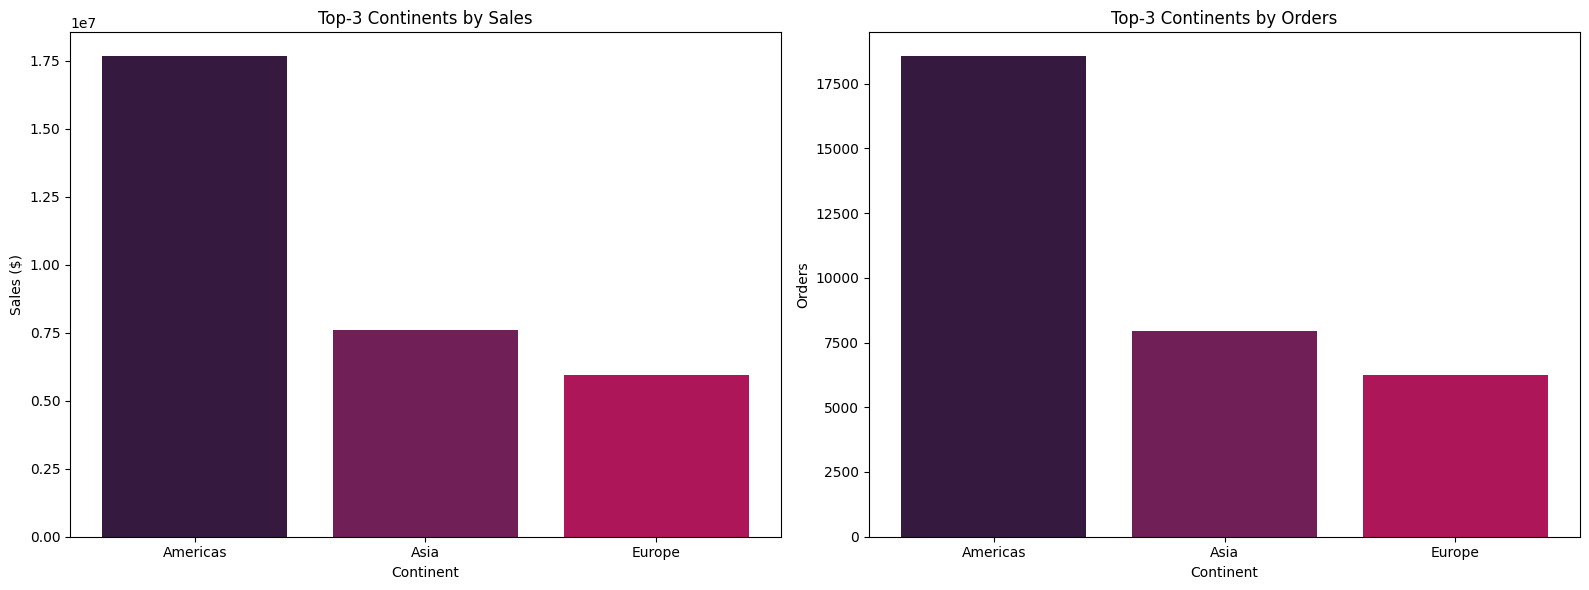

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(16, 6))
colors = sns.color_palette("rocket")

# Візуалізація Топ-3 континенти за сумою продажів
top_continent_sales = df.groupby("continent")["price"].sum().sort_values(ascending=False).head(3)
ax[0].bar(top_continent_sales.index, top_continent_sales.values, color=colors)
ax[0].set_title("Top-3 Continents by Sales")
ax[0].set_xlabel("Continent")
ax[0].set_ylabel("Sales ($)")

# Візуалізація Топ-3 континенти за кількістю замовлень
top_continent_orders = df.groupby("continent")["price"].count().sort_values(ascending=False).head(3)
ax[1].bar(top_continent_orders.index, top_continent_orders.values, color=colors)
ax[1].set_title("Top-3 Continents by Orders")
ax[1].set_xlabel("Continent")
ax[1].set_ylabel("Orders")

plt.tight_layout()
plt.show()

Америка домінує як за обсягом продажів, так і за кількістю замовлень. Азія стабільно займає друге місце, а Європа — третє. Це демонструє сильні ринкові позиції Америки у порівнянні з іншими континентами. Пропорції між продажами і замовленнями майже ідентичні — це вказує на подібний середній чек.

## Топ-5 країн за найбільшими продажами та найбільшою кількістю замовлень

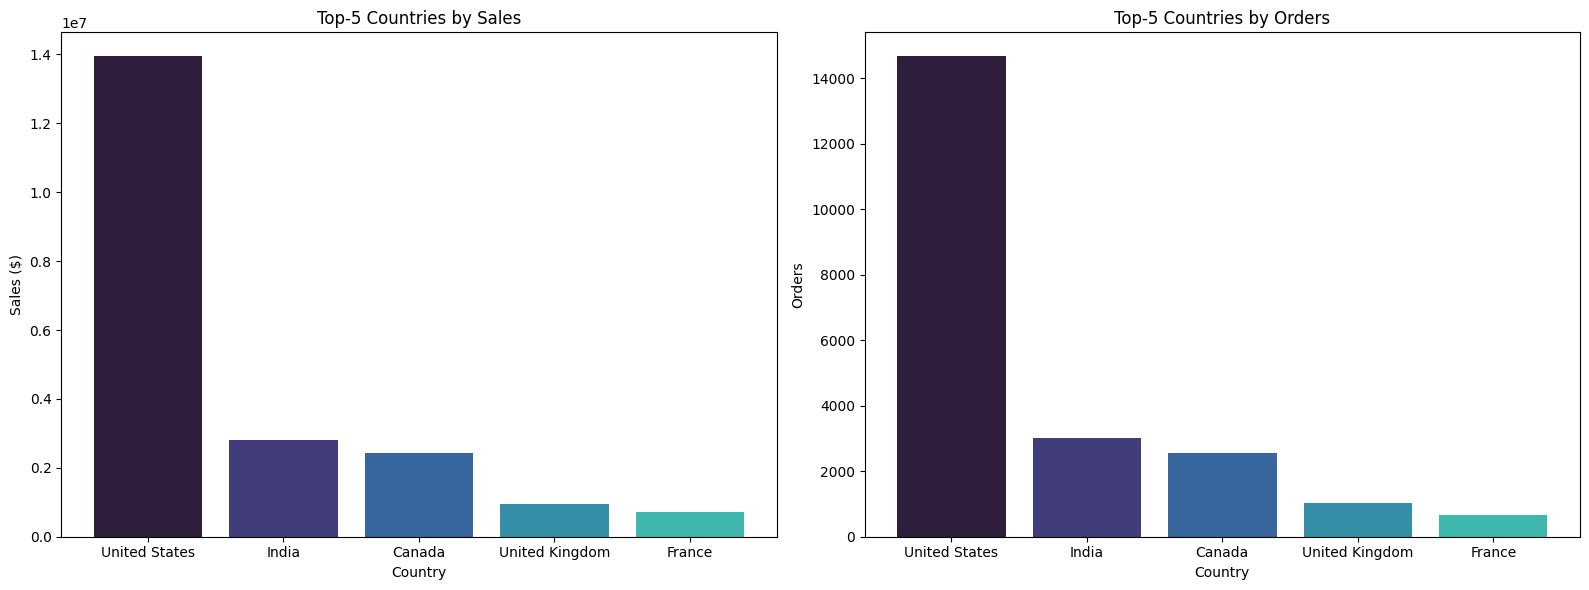

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(16, 6))
colors = sns.color_palette("mako")

# Візуалізація Топ-5 країн за сумою продажів
top_continent_sales = df.groupby("country")["price"].sum().sort_values(ascending=False).head(5)
ax[0].bar(top_continent_sales.index, top_continent_sales.values, color=colors)
ax[0].set_title("Top-5 Countries by Sales")
ax[0].set_xlabel("Country")
ax[0].set_ylabel("Sales ($)")

# Візуалізація Топ-5 країн за кількістю замовлень
top_continent_orders = df.groupby("country")["price"].count().sort_values(ascending=False).head(5)
ax[1].bar(top_continent_orders.index, top_continent_orders.values, color=colors)
ax[1].set_title("Top-5 Countries by Orders")
ax[1].set_xlabel("Country")
ax[1].set_ylabel("Orders")

plt.tight_layout()
plt.show()

США є домінуючим ринком за обсягом продажів і кількістю замовлень, формуючи основну частину доходу. Індія та Канада демонструють стабільні, але значно менші показники, тоді як Велика Британія та Франція мають обмежений внесок. Продажі прямо корелюють із кількістю замовлень, що вказує на доцільність фокусу на ключових та перспективних ринках.

## Топ-10 категорій товарів за сумою продажів та у країні з найбільшими продажами

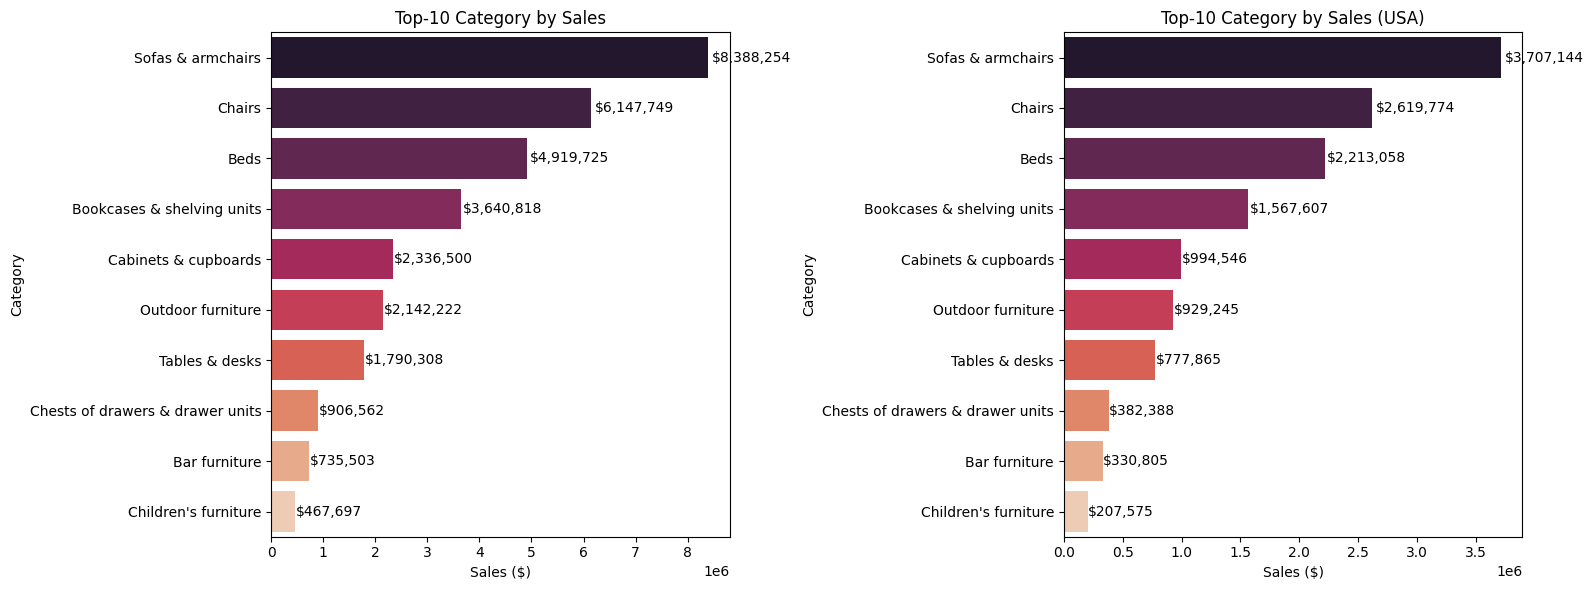

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# Візуалізація Топ-10 категорій товарів за сумою продажів
top_category_sales = df.groupby("category")["price"].sum().sort_values(ascending=False).head(10)
palette = sns.color_palette("rocket", len(top_category_sales))
sns.barplot(x=top_category_sales.values, y=top_category_sales.index, hue=top_category_sales.index, palette=palette, legend=False, ax=ax[0])
ax[0].set_title("Top-10 Category by Sales")
ax[0].set_xlabel("Sales ($)")
ax[0].set_ylabel("Category")

for i, v in enumerate(top_category_sales.values):
    ax[0].text(v + v*0.01, i, f"${v:,.0f}", va='center')

# Візуалізація Топ-10 категорій товарів у країні з найбільшими продажами
df_usa = df[df["country"] == "United States"]
top_category_sales_usa = df_usa.groupby("category")["price"].sum().sort_values(ascending=False).head(10)
palette = sns.color_palette("rocket", len(top_category_sales_usa))
sns.barplot(x=top_category_sales_usa.values, y=top_category_sales_usa.index, hue=top_category_sales_usa.index, palette=palette, legend=False, ax=ax[1])
ax[1].set_title("Top-10 Category by Sales (USA)")
ax[1].set_xlabel("Sales ($)")
ax[1].set_ylabel("Category")

for i, v in enumerate(top_category_sales_usa.values):
    ax[1].text(v + v*0.01, i, f"${v:,.0f}", va='center')

plt.tight_layout()
plt.show()

Аналіз показує, що:
   * ситуація на ринку США повністю ідентична загальній структурі продажів.
   * США є країною з найбільшими продажами (приблизно 44% від загальних продажів по всіх топ-категоріях).
   * переваги споживачів у США значною мірою визначають загальну структуру продажів.

## Продажі у розрізі девайсів та каналів трафіку

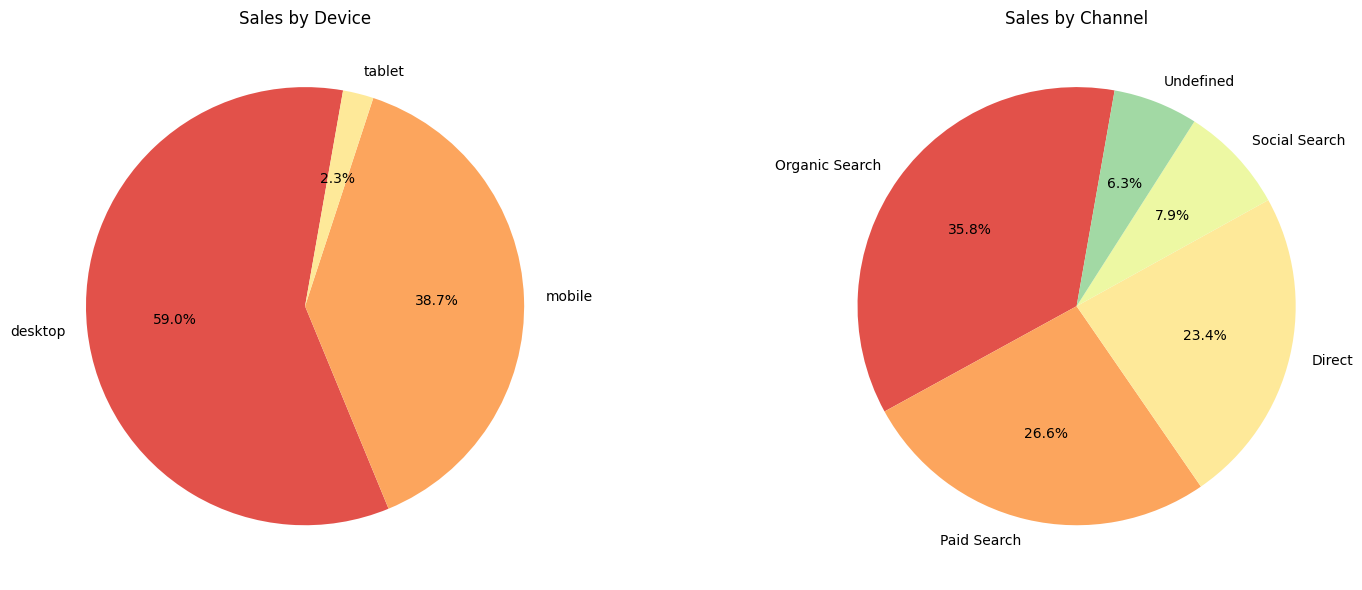

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(16,6))
colors = sns.color_palette("Spectral")

# Візуалізація продажів по девайсах
sales_by_device = df.groupby('device')['price'].sum().sort_values(ascending=False)
ax[0].pie(sales_by_device, labels=sales_by_device.index, autopct='%1.1f%%', startangle=80, colors=colors)
ax[0].set_title("Sales by Device")

# Візуалізація продажів по каналах трафіку
sales_by_channel = df.groupby('channel')['price'].sum().sort_values(ascending=False)
ax[1].pie(sales_by_channel, labels=sales_by_channel.index, autopct='%1.1f%%', startangle=80, colors=colors)
ax[1].set_title("Sales by Channel")

plt.tight_layout()
plt.show()

### Продажі за типами девайсів:

Користувачі частіше завершують покупку через десктопну версію сайту (59%), що може бути пов'язано зі зручністю перегляду та оформлення замовлення на великому екрані. Частка продажів через мобільні пристрої (38.7%) підтверджує важливість мобільної оптимізації сайту. Продажі з планшетів майже не впливають на загальні — лише 2.3%.

### Продажі за типами каналами трафіку:
* Органічний пошук (35.8%) — найефективніше джерело трафіку, що генерує більше третини всіх продажів.
* Платний пошук (26.6%) демонструє добрі результати, забезпечуючи понад чверть продажів.
* Прямий трафік (23.4%) - є третів за важливістю.
* Соціальні мережі (7,9%) та Невизначене джерело трафіку (6,3%) мають найменшу частку.

# Аналіз поведінки користувачів: підписка, верифікація та географія

In [ ]:
# Обчислюємо відсоток зараєстрованих користувачів, які підтвердили свій email
registered_users = df[df['account_id'].notna()]  # вибираємо тільки зареєстрованих
verified_count = registered_users['is_verified'].sum()  # підсумовуємо True як 1
total_registered = len(registered_users)

percent_verified = (verified_count / total_registered) * 100
print(f"{percent_verified:.1f}% зареєстрованих користувачів підтвердили email")

71.7% зареєстрованих користувачів підтвердили email


In [ ]:
# Обчислюємо відсоток зараєстрованих користувачів, які відписались від розсилки
registered_users = df[df['account_id'].notna()]
unsubscribed_count = registered_users['is_unsubscribed'].sum()
total_registered = len(registered_users)

percent_unsubscribed = (unsubscribed_count / total_registered) * 100
print(f"{percent_unsubscribed:.1f}% зареєстрованих користувачів відписались від розсилки")

16.9% зареєстрованих користувачів відписались від розсилки


In [ ]:
# Обчислюємо статистику користувачів, які залишились підписаними та які відписались
print(f"Статистика користувачів, які залишились підписаними:\n{df[df['is_unsubscribed'] == 0]['price'].describe()}\n")
print(f"Статистика користувачів, які відписались від розсилки:\n{df[df['is_unsubscribed'] == 1]['price'].describe()}")

Статистика користувачів, які залишились підписаними:
count    2334.000000
mean      921.506812
std      1323.918182
min         3.000000
25%       149.000000
50%       395.000000
75%      1100.000000
max      8900.000000
Name: price, dtype: float64

Статистика користувачів, які відписались від розсилки:
count     447.000000
mean      965.820134
std      1298.176986
min         3.000000
25%       175.000000
50%       450.000000
75%      1297.500000
max      8900.000000
Name: price, dtype: float64


In [ ]:
# Знаходимо країни в яких найбільше зареєстрованих користувачів
registered_users = df[df['account_id'].notna()]
top_country_registered = registered_users.groupby('country')['ga_session_id'].count().sort_values(ascending=False).head(10)
top_country_registered

,ga_session_id
country,
United States,12384
India,2687
Canada,2067
United Kingdom,859
France,553
Spain,536
Taiwan,500
China,490
Germany,490


### Рівень верифікації
71.7% зареєстрованих користувачів підтвердили свою електронну адресу,  що свідчить про високий рівень залученості та довіри.

### Відтік підписників
 16.9% зареєстрованих користувачів відписались від розсилки, що вказує на те, що помірна кількість клієнтів втрачає інтерес до маркетингових комунікацій.

### Поведінка в залежності від статусу підписки
Підписані користувачі:
* Кількість покупок: 2334
* Середній чек: 921.5
* Медіана: 395

Відписані користувачі:
* Кількість покупок: 447
* Середній чек: 965.8
* Медіана: 450

Існує помітна різниця у купівельній поведінці між групами користувачів. Користувачі, що залишились підписані роблять більшу кількість покупок, але середній чек та медіана менші ніж у користувачів, які відписались від розсилки. Це означає, що відписка не впливає зниження купівельної активності.

### Географічний розподіл
Топ-3 країни з найбільшою кількістю зареєстрованих користувачів є ідентичними до топ-3 країн з найбільшими продажами та найбільшою кількістю замовлень.

США є абсолютним лідером, там спостерігається найбільша кількість зареєстрованих користувачів (12384), що майже вп'ятеро перевищує другу за величиною базу в Індії (2687). Канада посідає третє місце з 2067 користувачами.

# Аналіз динаміки продажів

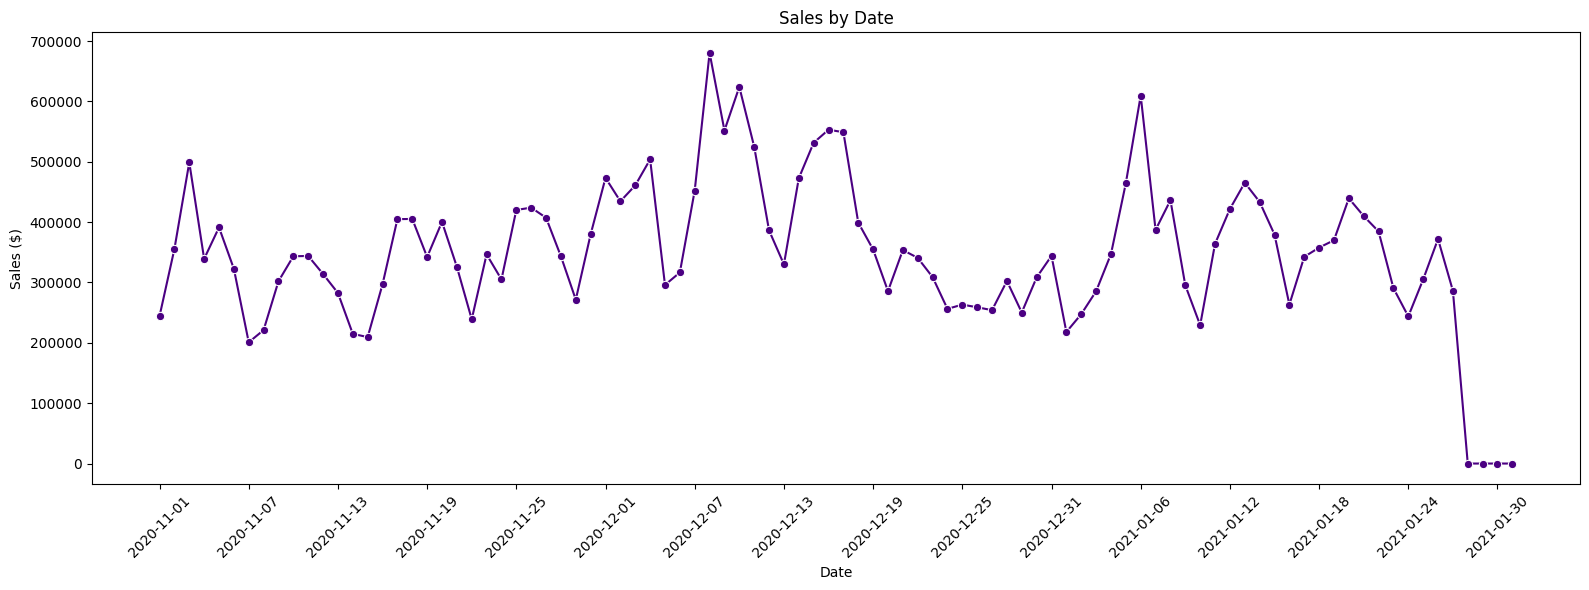

In [ ]:
plt.figure(figsize=(16, 6))
colors = sns.color_palette("mako")

# Візуалізація динаміки продажів у часі
sales_by_date = df.groupby('date')['price'].sum()
sns.lineplot(x=sales_by_date.index, y=sales_by_date.values, marker='o', color='indigo')
plt.title('Sales by Date')
plt.xlabel('Date')
plt.ylabel('Sales ($)')
plt.xticks(pd.date_range(df["date"].min(), df["date"].max(), freq="6D"), rotation=45)

plt.tight_layout()
plt.show()

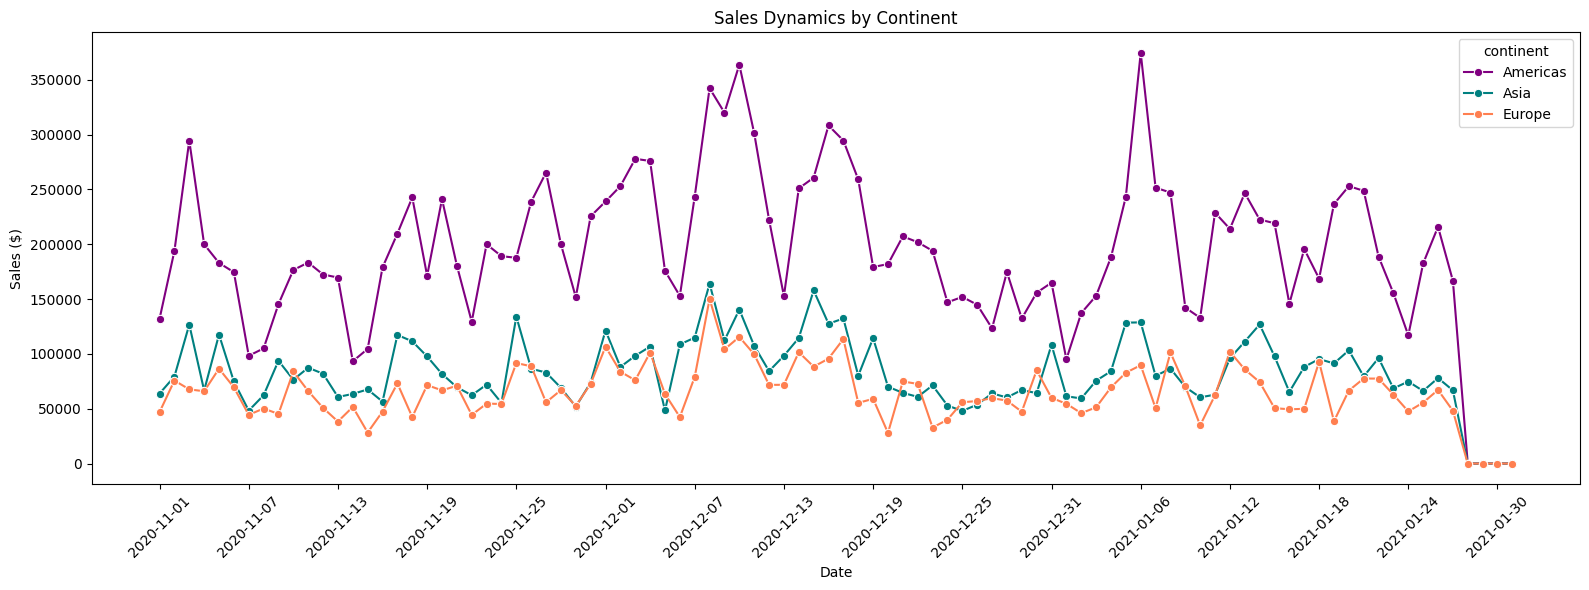

In [ ]:
plt.figure(figsize=(16, 6))

# Візуалізація динаміки продажів по континентах
continent_sales = df[df['continent'].isin(['Americas', 'Asia', 'Europe'])]
continent_group = continent_sales.groupby(['date', 'continent'])['price'].sum().reset_index()
sns.lineplot(data=continent_group, x='date', y='price', hue='continent', marker='o', palette=['purple','teal', 'coral'])
plt.title('Sales Dynamics by Continent')
plt.xlabel('Date')
plt.ylabel('Sales ($)')
plt.xticks(pd.date_range(df["date"].min(), df["date"].max(), freq="6D"), rotation=45)

plt.tight_layout()
plt.show()

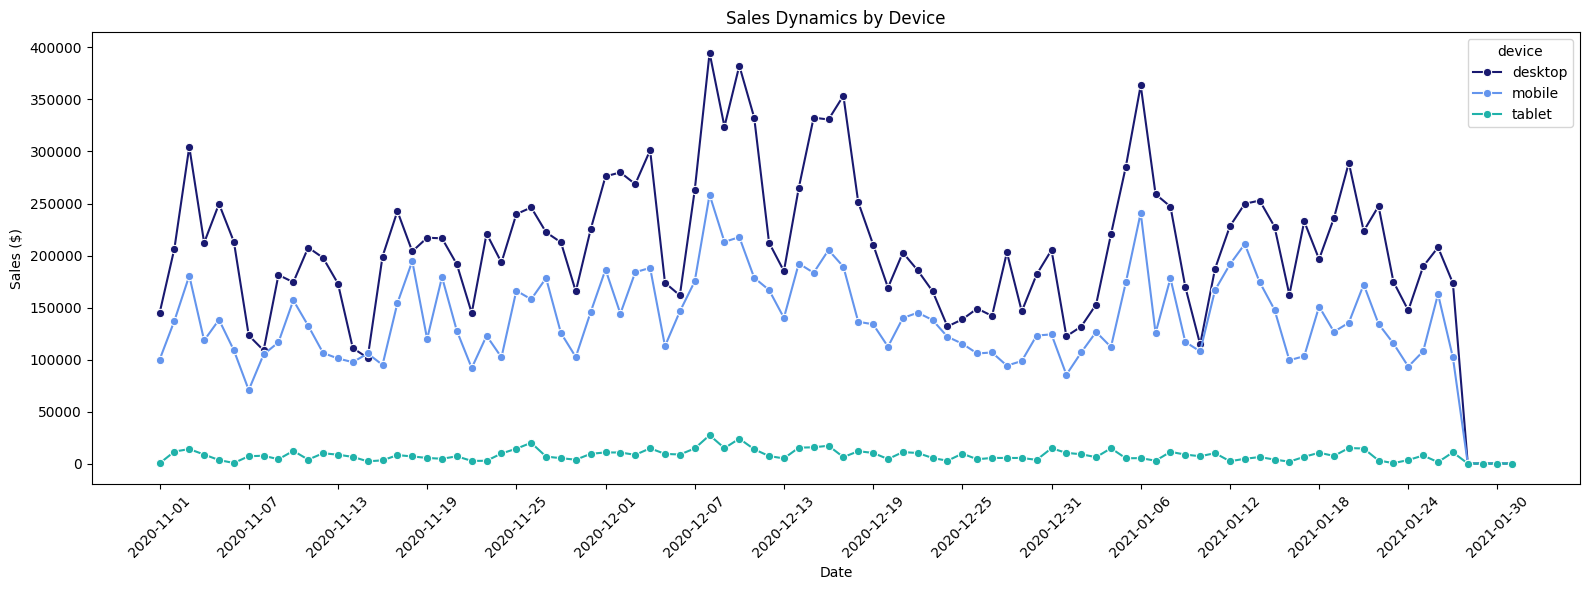

In [ ]:
plt.figure(figsize=(16, 6))

# Візуалізація динаміки продажів у розрізі типів девайсів
device_group = df.groupby(['date', 'device'])['price'].sum().reset_index()
sns.lineplot(data=device_group, x='date', y='price', hue='device', marker='o', palette=['midnightblue','cornflowerblue', 'lightseagreen'])
plt.title('Sales Dynamics by Device')
plt.xlabel('Date')
plt.ylabel('Sales ($)')
plt.xticks(pd.date_range(df["date"].min(), df["date"].max(), freq="6D"), rotation=45)

plt.tight_layout()
plt.show()

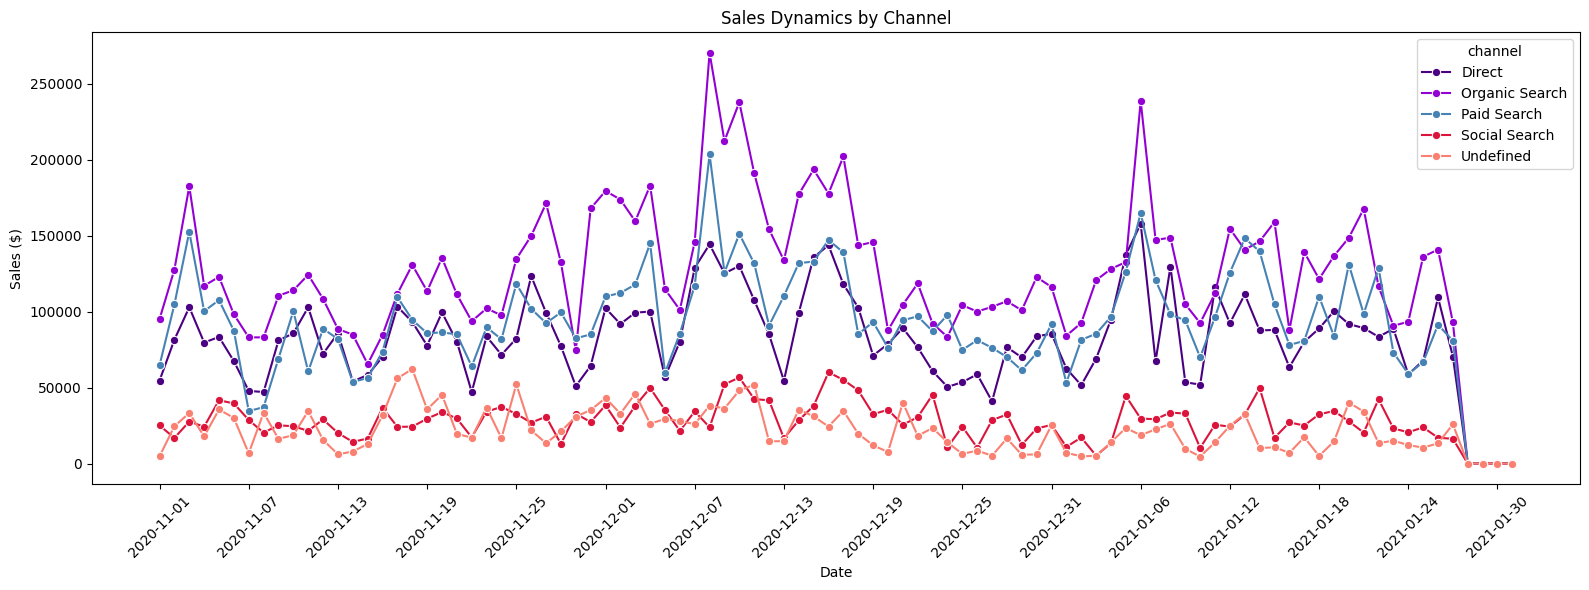

In [ ]:
plt.figure(figsize=(16, 6))

# Візуалізація динаміки продажів у розрізі каналів трафіку
channel_group = df.groupby(['date', 'channel'])['price'].sum().reset_index()
sns.lineplot(data=channel_group, x='date', y='price', hue='channel', marker='o', palette=['indigo','darkviolet', 'steelblue', 'crimson', 'salmon'])
plt.title('Sales Dynamics by Channel')
plt.xlabel('Date')
plt.ylabel('Sales ($)')
plt.xticks(pd.date_range(df["date"].min(), df["date"].max(), freq="6D"), rotation=45)

plt.tight_layout()
plt.show()

### Загальні продажі за кожну дату та сезонність продажів
Протягом всього періоду можна зауважити тижневу циклічність з піками та спадами кожні кілька днів, це може означати зростання продажів у вихідні та спад на початку робочого тижня.

Піки продажів:
* Кінець листопада-перша половина грудня - може вказувати на передсвяткову сезонність (Black Friday, Cyber Monday, передноворічні покупки).
* Початок січня - високі продажі можливо пов'язані з новорічними розпродажами.

Одразу після цих піків спостерігається спад продажів, що може бути пов’язано з завершенням свят і зменшенням активності покупців.

### Динаміка продажів по континентах, типах девайсів та каналів трафіку
Аналогічно до графіка загальної динаміки продажів, сезонність продажів простежується на всіх трьох графіках з чітко вираженими піками з кінця листопада до середини грудня та на початку січня. Це свідчить про те, що святкові періоди є головним драйвером продажів у всіх сегментах.

Лідери серед сегментів:
* За континентами: Америка є лідером та генерує понад 50% загальних продажів.
* За пристроями: Desktop домінує за обсягами продажів.
* За каналами трафіку: Organic Search приносить найбільший результат.

# Зведені таблиці

## Кількість сесій за типами девайсів

In [ ]:
# Створємо зведену таблицю
pivot_table_session = pd.pivot_table(df, values="ga_session_id", index="channel", columns="device", aggfunc="count")

print('Кількість сесій у розрізі каналів трафіку та типів девайсів:')
display(pivot_table_session.style.background_gradient(cmap="YlOrRd"))

Кількість сесій у розрізі каналів трафіку та типів девайсів:


device,desktop,mobile,tablet
channel,,,
Direct,47825,31745,1812
Organic Search,72622,49014,2789
Paid Search,55167,37034,2140
Social Search,16288,10988,638
Undefined,12527,8486,470


In [ ]:
# Замінюємо Nan на 'Other'
df['browser'] = df['browser'].replace('<Other>', 'Other')

# Створємо зведену таблицю
pivot_table_session_count = pd.pivot_table(df, values="ga_session_id", index="browser", columns="device", aggfunc="count", fill_value=0)

print('Кількість сесій у розрізі браузерів та типів девайсів:')
display(pivot_table_session_count.style.background_gradient(cmap="YlOrRd"))

Кількість сесій у розрізі браузерів та типів девайсів:


device,desktop,mobile,tablet
browser,,,
Android Webview,0,4227,218
Chrome,171859,62706,3895
Edge,8016,7,0
Firefox,6063,370,0
Other,2313,6000,617
Safari,16178,63957,3119


* Desktop — основний тип девайсу.
* Chrome і Safari — ключові браузери. Chrome є лідером на десктоп, а Safari на мобільних пристроях.
* Organic Search — головне джерело трафіку на всіх девайсах.

## Продажі за категоріями товарів

In [ ]:
top_countries = df.groupby('country')['price'].sum().sort_values(ascending=False).head(5).index
top_category = df.groupby('category')['price'].sum().sort_values(ascending=False).head(10).index

# Фільтруємо дані
top_countries_category = df[(df["country"].isin(top_countries)) & (df["category"].isin(top_category))]

# Створюємо зведену таблицю
pivot_table_sales = pd.pivot_table(top_countries_category, values="price", index='category', columns="country", aggfunc="sum")
print('Загальні продажі за категоріями товарів у різних країнах:')
display(pivot_table_sales.style.background_gradient(cmap="YlOrRd").format("{:.2f}"))

Загальні продажі за категоріями товарів у різних країнах:


country,Canada,France,India,United Kingdom,United States
category,,,,,
Bar furniture,51724.00,11199.00,57657.00,22103.00,330805.00
Beds,354772.00,116414.00,358319.50,133816.00,2213058.00
Bookcases & shelving units,278981.90,73830.00,364507.40,113987.60,1567606.90
Cabinets & cupboards,181802.00,59101.50,191888.00,71684.50,994545.50
Chairs,417740.80,134029.40,544309.20,188519.40,2619773.80
Chests of drawers & drawer units,71952.00,21544.50,73111.00,36784.00,382388.00
Children's furniture,30264.00,14258.00,39177.00,13348.00,207575.00
Outdoor furniture,185322.80,40486.40,162289.40,57002.40,929245.20
Sofas & armchairs,692427.50,187735.00,788430.00,234812.00,3707144.50


In [ ]:
channels = df['channel'].unique()
top_category = df.groupby('category')['price'].sum().sort_values(ascending=False).head(10).index

# Фільтруємо дані
top_channel_category = df[(df["channel"].isin(channels)) & (df["category"].isin(top_category))]

# Створюємо зведену таблицю
pivot_table_sales = pd.pivot_table(top_channel_category, values="price", index='category', columns="channel", aggfunc="sum")
print('Загальні продажі за категоріями товарів у розрізі джерел трафіку:')
display(pivot_table_sales.style.background_gradient(cmap="YlOrRd").format("{:.2f}"))

Загальні продажі за категоріями товарів у розрізі джерел трафіку:


channel,Direct,Organic Search,Paid Search,Social Search,Undefined
category,,,,,
Bar furniture,164452.00,257176.00,195842.00,61183.00,56850.00
Beds,1130173.00,1808148.00,1300249.00,370773.00,310382.00
Bookcases & shelving units,833634.10,1309674.20,986162.20,287311.40,224036.20
Cabinets & cupboards,549938.50,853306.50,617867.50,190254.00,125133.00
Chairs,1454728.00,2192944.60,1658668.60,479799.40,361608.20
Chests of drawers & drawer units,210388.00,309112.00,245290.00,74425.00,67347.50
Children's furniture,117089.00,173211.00,111367.00,37475.00,28555.00
Outdoor furniture,542934.80,745654.80,554746.60,156038.40,142847.60
Sofas & armchairs,1990622.00,2925362.00,2214168.50,710012.00,548090.00


Найпопулярніші категорії:
* Sofas & armchairs - беззаперечний лідер за виручкою в усіх країнах.
* Chairs та Beds - стабільно займають 2 та 3 місця.

Саме вони є ключовими драйверами виручки.

У розрізі країн Сполучені Штати є абсолютним лідером за обсягом продажів у всіх категоріях. Індія та Канада займають наступні місця - ці ринки є перспективними для масштабування.

У розрізі джерел трафіку Organic Search — головний драйвер продажів у всіх категоріях. Paid Search та Direct також мають значний вклад.

# Статистичний аналіз взаємозв’язків

## Кореляція між кількістю сесій та загальними продажами за кожну дату

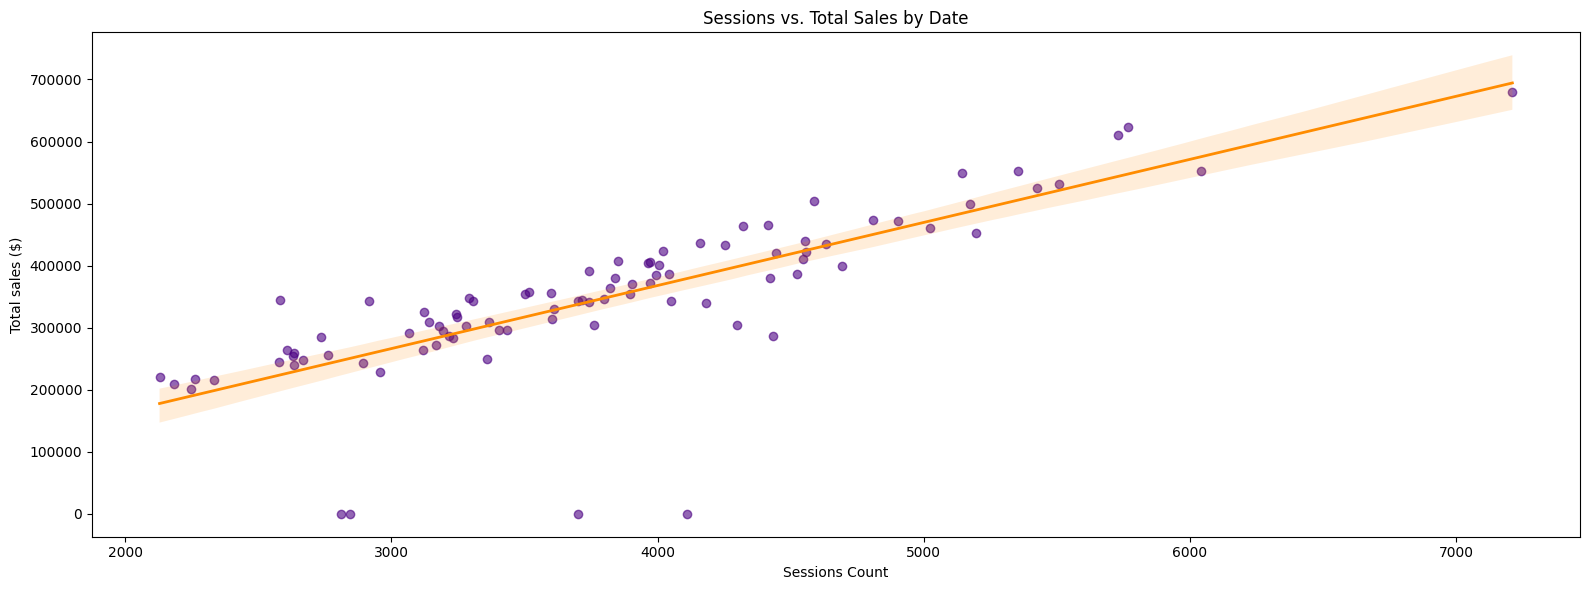

In [ ]:
# Агрегуємо дані по даті
day_agg = (df.groupby('date').agg(sessions=('ga_session_id', 'nunique'), sales=('price', 'sum')).reset_index())

# Візуалізація зв'язку між кількістю сесій та загальними продажами у часі
plt.figure(figsize=(16, 6))

sns.regplot(data=day_agg, x='sessions', y='sales', scatter_kws={'color': 'indigo', 'alpha': 0.6}, line_kws={'color': 'darkorange', 'linewidth': 2})
plt.title('Sessions vs. Total Sales by Date')
plt.xlabel('Sessions Count')
plt.ylabel('Total sales ($)')

plt.tight_layout()
plt.show()

In [ ]:
from scipy.stats import pearsonr, spearmanr

# Обчислюємо коефіцієнт кореляції та статистичну значущість (p-value)
pearson_corr, pearson_p = pearsonr(day_agg['sessions'], day_agg['sales'])
spearman_corr, spearman_p = spearmanr(day_agg['sessions'], day_agg['sales'])

print(f'Pearson correlation:', pearson_corr)
print(f'p-value:', pearson_p)
print(f'Spearman correlation:', spearman_corr)
print(f'p-value:', spearman_p)

Pearson correlation: 0.7910809164540891
p-value: 6.483532312080735e-21
Spearman correlation: 0.8653062174563682
p-value: 9.755923586156614e-29


Візуальний аналіз свідчить про лінійний позитивний зв’язок між кількістю сесій та обсягом продажів, тому для основного аналізу було використано коефіцієнт кореляції Пірсона. Додатково було розраховано коефіцієнт Спірмена для перевірки стійкості результатів до наявних викидів. Обидва коефіцієнти підтверджують наявність статистично значущого позитивного зв’язку.

## Кореляція між продажами на топ-3 континентах

In [ ]:
# Визначаємо топ-3 континенти за продажами
top_continents = df.groupby('continent')['price'].sum().sort_values(ascending=False).head(3).index

# Агрегуємо продажі по даті та континентах
continent_sales_by_day = (df[df['continent'].isin(top_continents)].groupby(['date', 'continent'])['price'].sum().reset_index())

# Сторюємо pivot table для кореляції
sales_pivot_continent = (continent_sales_by_day.pivot(index='date', columns='continent', values='price').dropna())
print("Таблиця для кореляції:\n", sales_pivot_continent.head())

from scipy.stats import pearsonr
from itertools import combinations

# Обчислюємо статистичну значущість (p-value)
results = []
for c1, c2 in combinations(sales_pivot_continent.columns, 2):
    _, p_value = pearsonr(sales_pivot_continent[c1], sales_pivot_continent[c2])

    results.append({
        'continent_1': c1,
        'continent_2': c2,
        'p_value': p_value
    })

corr_results = pd.DataFrame(results)
print("\np-value:\n", corr_results)

Таблиця для кореляції:
 continent   Americas      Asia   Europe
date                                   
2020-11-01  132002.5   63823.0  46908.0
2020-11-02  193861.0   79370.0  75710.8
2020-11-03  294529.8  126737.8  67692.0
2020-11-04  200009.5   66602.0  65915.0
2020-11-05  182988.2  117608.4  86540.0

p-value:
   continent_1 continent_2       p_value
0    Americas        Asia  5.409189e-21
1    Americas      Europe  2.671449e-19
2        Asia      Europe  3.864946e-19


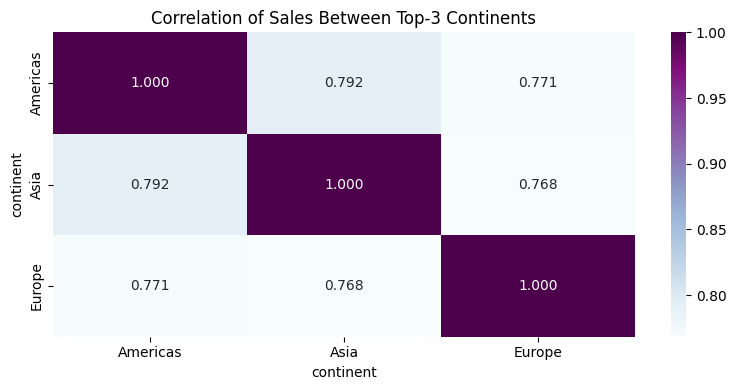

In [ ]:
# Кореляція між континентами за методом Пірсона
corr_matrix = sales_pivot_continent.corr(method='pearson')

# Візуалізація кореляції
plt.figure(figsize=(8, 4))
sns.heatmap(corr_matrix, annot=True, cmap='BuPu', fmt=".3f")
plt.title('Correlation of Sales Between Top-3 Continents')

plt.tight_layout()
plt.show()

Аналіз показав наявність сильних позитивних та статистично значущих кореляцій між щоденними продажами на континентах. Для всіх пар коефіцієнт кореляції Пірсона знаходяться в межах 0.76–0.79, а p-value є значно меншим за 0.05. Це свідчить про синхронну динаміку продажів між континентами.

## Кореляція між продажами за каналами трафіку

In [ ]:
# Агрегуємо продажі по даті та каналу трафіку
channel_sales_by_day = (df.groupby(['date', 'channel'])['price'].sum().reset_index())

# Створюємо pivot table для кореляції
sales_pivot_channel = (channel_sales_by_day.pivot(index='date', columns='channel', values='price').dropna())
print("Таблиця для кореляції:\n", sales_pivot_channel.head())

from scipy.stats import pearsonr
from itertools import combinations

# Обчислюємо статистичну значущість (p-value)
results = []
for ch1, ch2 in combinations(sales_pivot_channel.columns, 2):
    _, p_value = pearsonr(sales_pivot_channel[ch1], sales_pivot_channel[ch2])

    results.append({
        'channel_1': ch1,
        'channel_2': ch2,
        'p_value': p_value
    })

corr_results_channels = pd.DataFrame(results)
print("\np-value:\n", corr_results_channels)

Таблиця для кореляції:
 channel       Direct  Organic Search  Paid Search  Social Search  Undefined
date                                                                       
2020-11-01   54669.5         95112.0      64688.0        25078.0     4745.0
2020-11-02   81561.5        127746.5     104780.8        16843.0    24575.0
2020-11-03  102909.5        182521.9     152641.3        27652.5    33254.4
2020-11-04   79683.6        117067.1     100332.0        24257.4    17847.0
2020-11-05   83367.6        122938.4     107648.0        41693.2    35629.4

p-value:
         channel_1       channel_2       p_value
0          Direct  Organic Search  2.190420e-25
1          Direct     Paid Search  5.896435e-23
2          Direct   Social Search  1.831889e-10
3          Direct       Undefined  1.275436e-07
4  Organic Search     Paid Search  2.142003e-29
5  Organic Search   Social Search  1.066192e-09
6  Organic Search       Undefined  7.228214e-08
7     Paid Search   Social Search  3.532284e-10
8

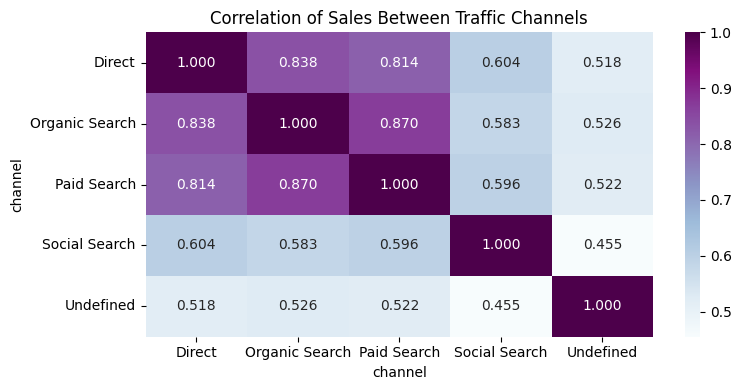

In [ ]:
# Кореляція між каналами за методом Пірсона
corr_matrix_channels = sales_pivot_channel.corr(method='pearson')

# Візуалізація кореляції
plt.figure(figsize=(8, 4))
sns.heatmap(corr_matrix_channels, annot=True, cmap='BuPu', fmt=".3f")
plt.title('Correlation of Sales Between Traffic Channels')

plt.tight_layout()
plt.show()

Аналіз показав, що між каналами трафіку спостерігається висока кореляція продажів, і ці взаємозв’язки є статистично значущими. Найсильніші зв’язки — між Direct, Organic Search та Paid Search (коефіцієнт кореляції в межах 0.81-0.87 та p-value < 0.05), що свідчить про синхронність їхніх продажів. Social Search та Undefined мають слабші, але все ще значущі зв’язки, що може вказувати на нестабільні джерела трафіку.

## Кореляція між продажами за топ-5 категоріями товарів

In [ ]:
# Визначаємо топ-5 категорій за загальними продажами
top_5_categories = (df.groupby('category')['price'].sum().sort_values(ascending=False).head(5).index)

# Агрегуємо продажі по даті для топ-5 категорій
category_sales_by_day = (df[df['category'].isin(top_5_categories)].groupby(['date', 'category'])['price'].sum().reset_index())

# Створюємо pivot table для кореляції
sales_pivot_category = (category_sales_by_day.pivot(index='date', columns='category', values='price').dropna())
print("Таблиця для кореляції:\n", sales_pivot_category.head())

from scipy.stats import pearsonr
from itertools import combinations

# Обчислюємо статистичну значущість (p-value)
results = []
for cat1, cat2 in combinations(sales_pivot_category.columns, 2):
    _, p_value = pearsonr(sales_pivot_category[cat1],sales_pivot_category[cat2])

    results.append({
        'category_1': cat1,
        'category_2': cat2,
        'p_value': p_value
    })

corr_results_categories = pd.DataFrame(results)
print("\np-value:\n", corr_results_categories)

Таблиця для кореляції:
 category       Beds  Bookcases & shelving units  Cabinets & cupboards  \
date                                                                    
2020-11-01  14041.0                     36701.0               13591.5   
2020-11-02  79683.5                     40979.0               21623.0   
2020-11-03  66219.5                     64360.1               33555.5   
2020-11-04  48939.0                     35719.8               19266.0   
2020-11-05  23449.0                     40998.8               29235.0   

category     Chairs  Sofas & armchairs  
date                                    
2020-11-01  46006.0            75216.0  
2020-11-02  58834.0            79977.5  
2020-11-03  61204.0           175594.0  
2020-11-04  44113.0            86861.5  
2020-11-05  90388.4           137288.0  

p-value:
                    category_1                  category_2       p_value
0                        Beds  Bookcases & shelving units  1.154998e-09
1                     

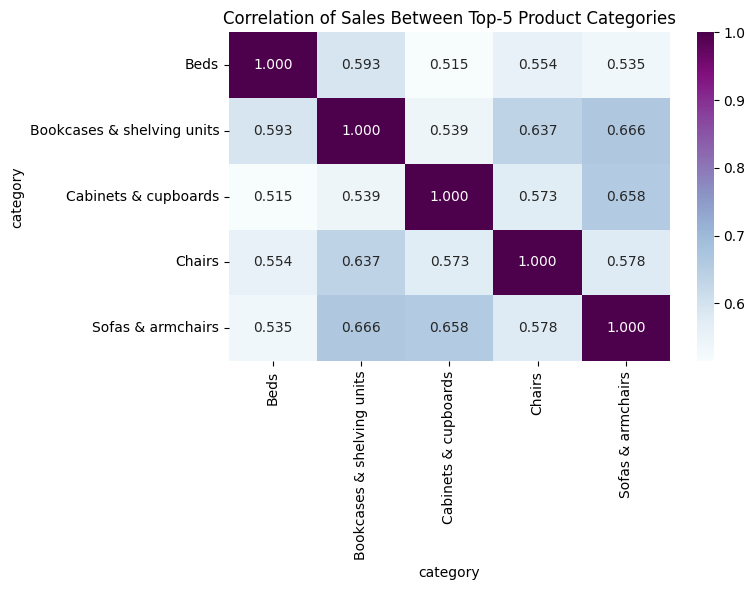

In [ ]:
# Кореляція між категоріями за методом Пірсона
corr_matrix_categories = sales_pivot_category.corr(method='pearson')

# Візуалізація кореляції
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix_categories, annot=True, cmap='BuPu', fmt=".3f")
plt.title('Correlation of Sales Between Top-5 Product Categories')

plt.tight_layout()
plt.show()

Аналіз показав, що між топ-5 категоріями товарів спостерігається помірна позитивна та статистично значуща кореляція (коефіцієнт кореляції в межах 0.51-0.66 та p-value < 0.05). Найвищі кореляції між Sofas & armchairs, Bookcases & shelving units та Cabinets & cupboards, що може свідчити про спільні сценарії покупок. Beds мають слабші, але все ще значущі зв’язки — можливо, їх купують не так часто або в інші періоди.

## Кореляція між продажами за типами девайсів

In [ ]:
# Агрегуємо продажі по даті та типу девайсу
device_sales_by_day = ( df.groupby(['date', 'device'])['price'].sum().reset_index())

# Створюємо pivot table для кореляції
sales_pivot_device = (device_sales_by_day.pivot(index='date', columns='device', values='price').dropna())
print("Таблиця для кореляції:\n", sales_pivot_device.head())

from scipy.stats import pearsonr
from itertools import combinations

# Обчислюємо статистичну значущість (p-value)
results = []
for d1, d2 in combinations(sales_pivot_device.columns, 2):
    _, p_value = pearsonr(sales_pivot_device[d1], sales_pivot_device[d2])

    results.append({
        'device_1': d1,
        'device_2': d2,
        'p_value': p_value
    })

corr_results_devices = pd.DataFrame(results)
print("\np-value:\n", corr_results_devices)

Таблиця для кореляції:
 device       desktop    mobile   tablet
date                                   
2020-11-01  144445.0   99698.5    149.0
2020-11-02  206727.3  137269.5  11510.0
2020-11-03  304473.8  180602.8  13903.0
2020-11-04  212227.7  118324.4   8635.0
2020-11-05  249682.0  138256.0   3338.6

p-value:
   device_1 device_2       p_value
0  desktop   mobile  7.719911e-30
1  desktop   tablet  2.316806e-10
2   mobile   tablet  3.693817e-09


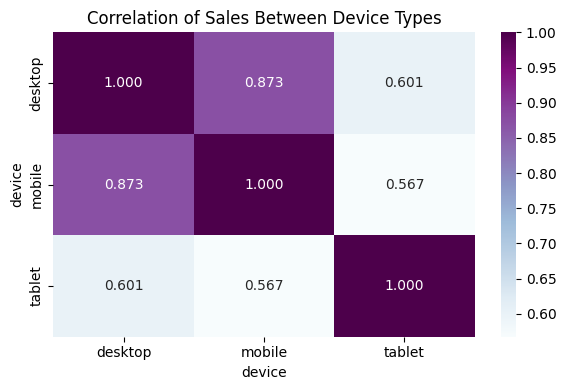

In [ ]:
# Кореляція між девайсами за методом Пірсона
corr_matrix_devices = sales_pivot_device.corr(method='pearson')

# Візуалізація кореляції
plt.figure(figsize=(6, 4))
sns.heatmap(corr_matrix_devices, annot=True, cmap='BuPu', fmt=".3f")
plt.title('Correlation of Sales Between Device Types')

plt.tight_layout()
plt.show()

Аналіз показав, що продажі за різними типами девайсів демонструють статистично значущу позитивну кореляцію, хоча сила зв’язку між ними різна. Найсильніша кореляція — між desktop і mobile (коефіцієнт кореляції 0.87), що свідчить про синхронність поведінки користувачів на цих платформах. Tablet має слабшу кореляцію з іншими типами (коефіцієнт кореляції в межах 0.56-0.6) — можливо, через меншу кількість транзакцій.

# Статистичний аналіз відмінностей між групами

## Аналіз продажів зареєстрованих та незареєстрованих користувачів

Shapiro–Wilk для зареєстрованих користувачів p-value: 0.007295139880540744
Shapiro–Wilk для незареєстрованих користувачів p-value: 0.0026183359245325936


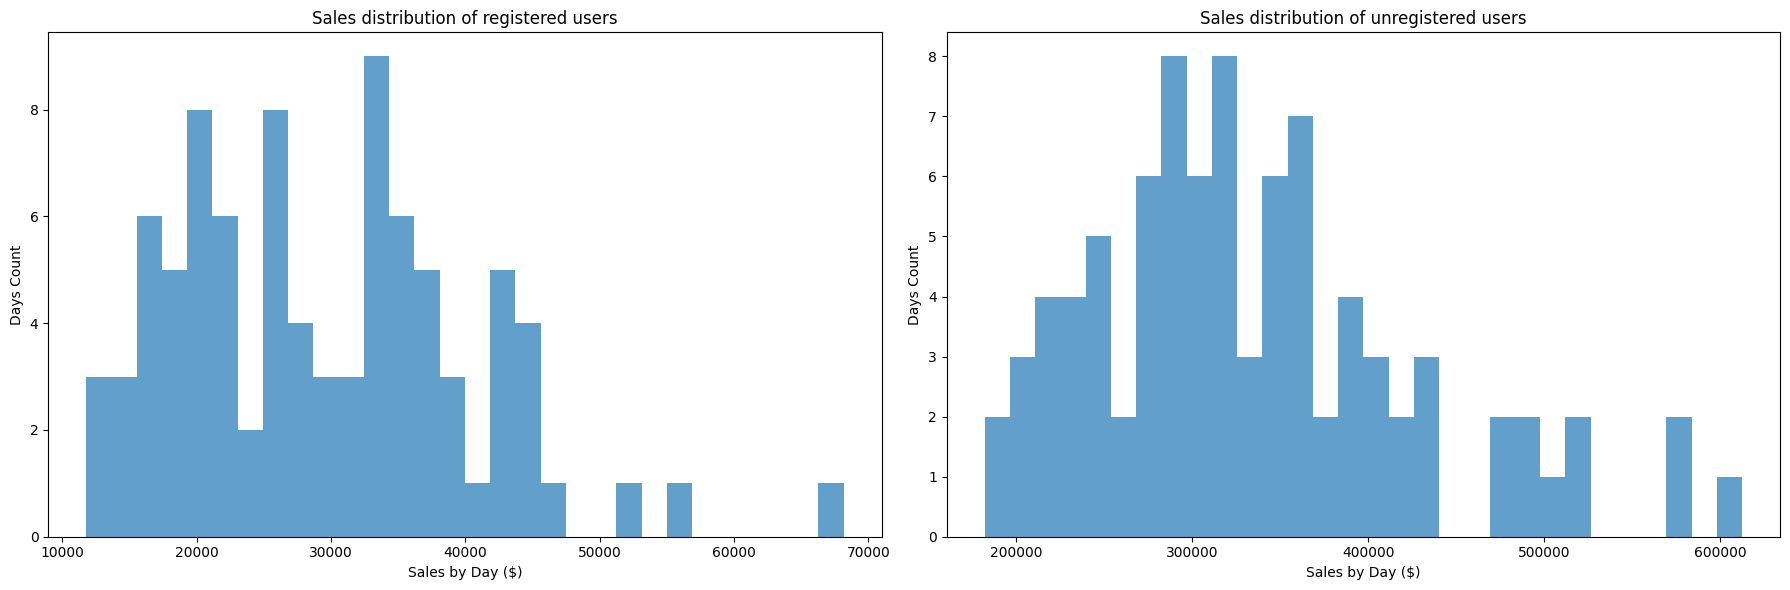

In [ ]:
# Вибираємо лише сесії з покупкою
df_sales = df.dropna(subset=['price']).copy()

# Вибираємо зареєстрованих користувачів
df_sales['is_verified'] = df_sales['account_id'].notna()

# Агрегуємо продажі по датах і типу користувача
daily_sales = (df_sales.groupby(['date', 'is_verified'])['price'].sum().reset_index())

registered_sales = daily_sales[daily_sales['is_verified'] == True]['price']
unregistered_sales = daily_sales[daily_sales['is_verified'] == False]['price']

# Перевірка на нормальність (Shapiro–Wilk)
from scipy.stats import shapiro

shapiro_reg = shapiro(registered_sales)
shapiro_unreg = shapiro(unregistered_sales)

print(f"Shapiro–Wilk для зареєстрованих користувачів p-value: {shapiro_reg.pvalue}")
print(f"Shapiro–Wilk для незареєстрованих користувачів p-value: {shapiro_unreg.pvalue}")

# Візуалізація розподілу
fig, ax = plt.subplots(1, 2, figsize=(18, 6))

# Зареєстровані користувачі
ax[0].hist(registered_sales, bins=30, alpha=0.7)
ax[0].set_title("Sales distribution of registered users")
ax[0].set_xlabel("Sales by Day ($)")
ax[0].set_ylabel("Days Count")

# Незареєстровані користувачі
ax[1].hist(unregistered_sales, bins=30, alpha=0.7)
ax[1].set_title("Sales distribution of unregistered users")
ax[1].set_xlabel("Sales by Day ($)")
ax[1].set_ylabel("Days Count")

plt.tight_layout()
plt.show()

In [ ]:
# Проведення статистичного тесту Mann–Whitney U
from scipy.stats import mannwhitneyu

stat, p_value = mannwhitneyu(registered_sales, unregistered_sales, alternative='two-sided')

print(f"U-статистика: {stat}")
print(f"P-value: {p_value}")

# Інтерпретація результатів
if p_value < 0.05:
    print("Існує статистично значуща різниця між середніми значеннями каналів трафіку.")
else:
    print("Статистично значущих відмінностей між середніми значеннями каналів трафіку не виявлено.")

U-статистика: 0.0
P-value: 2.2159276950123465e-30
Існує статистично значуща різниця між середніми значеннями каналів трафіку.


Аналіз розподілів щоденних продажів показав, що дані для зареєстрованих і незареєстрованих користувачів не відповідають нормальному розподілу (тест Shapiro–Wilk, p-value < 0.05). У зв’язку з цим для порівняння двох незалежних вибірок було застосовано непараметричний тест Mann–Whitney U. Результати тесту вказують на статистично значущу різницю між вибірками (p-value < 0.001), що свідчить про відмінності у рівні щоденних продажів між зареєстрованими та незареєстрованими користувачами.

## Аналіз кількості сесій за каналами трафіку

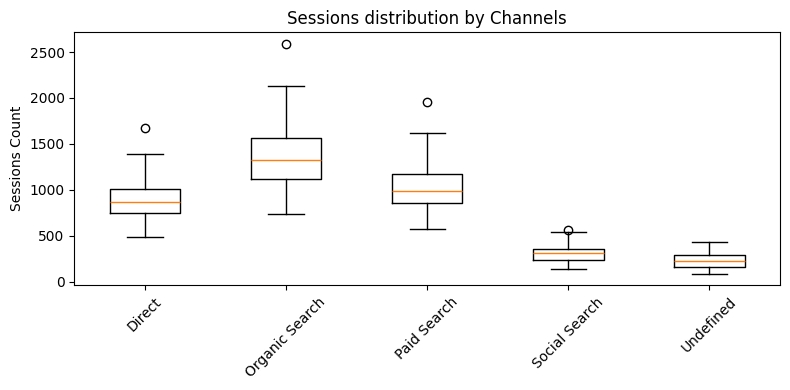

In [ ]:
# Обчислюємо сесії по датах та каналах трафіку
daily_sessions = (df.groupby(['date', 'channel'])['ga_session_id'].nunique().reset_index(name='sessions'))

channels = daily_sessions['channel'].unique()

plt.figure(figsize=(8, 4))
plt.boxplot([daily_sessions[daily_sessions['channel'] == ch]['sessions'] for ch in channels], tick_labels=channels, showfliers=True)
plt.xticks(rotation=45)
plt.title("Sessions distribution by Channels")
plt.ylabel("Sessions Count")

plt.tight_layout()
plt.show()

In [ ]:
# Проводимо тест Kruskal-Wallis
from scipy.stats import kruskal

samples = [daily_sessions[daily_sessions['channel'] == ch]['sessions']
    for ch in channels]

stat, p_value = kruskal(*samples)

print(f"Kruskal-Wallis statistic: {stat}")
print(f"P-value: {p_value}")

# Інтерпретація результатів
if p_value < 0.05:
    print("Існує статистично значуща різниця між середніми значеннями каналів трафіку.")
else:
    print("Статистично значущих відмінностей між середніми значеннями каналів трафіку не виявлено.")

Kruskal-Wallis statistic: 368.98057369864847
P-value: 1.397036102599359e-78
Існує статистично значуща різниця між середніми значеннями каналів трафіку.


Було проаналізовано кількість сесій у розрізі каналів трафіку на щоденному рівні. Візуальний аналіз розподілів показав суттєву асиметрію, різний масштаб значень та наявність викидів, що не відповідає припущенням параметричних методів. У зв’язку з цим для порівняння кількох незалежних груп було застосовано непараметричний тест Kruskal–Wallis.

Результати тесту вказують на статистично значущі відмінності в кількості сесій між каналами трафіку (H = 368.98, p-value < 0.001). Це означає, що канал трафіку має суттєвий вплив на обсяг залучених сесій, а спостережувані відмінності не є випадковими.

## Аналіз сесій з органічним трафіком у Європі та Америці

In [ ]:
# Вибираємо потрібні континенти
df_cont = df[df['continent'].isin(['Europe', 'Americas'])]

# Рахуємо загальну кількість сесій по континентах
total_sessions = (df_cont.groupby('continent')['ga_session_id'].nunique())

# Рахуємо кількість organic-сесій по континентах
organic_sessions = (df_cont[df_cont['channel'] == 'Organic Search'].groupby('continent')['ga_session_id'].nunique())

# Organic-сесії
organic_counts = [organic_sessions['Europe'], organic_sessions['Americas']]

# Загальна кількість сесій
total_counts = [total_sessions['Europe'], total_sessions['Americas']]

print(f"Organic sessions:\n  Europe: {organic_counts[0]}\n  America: {organic_counts[1]}")
print(f"Total sessions:\n  Europe: {total_counts[0]}\n  America: {total_counts[1]}")

# Проводимо тест пропорцій (z-тест)
from statsmodels.stats.proportion import proportions_ztest

stat, p_value = proportions_ztest(organic_counts, total_counts)

print("\nZ-statistic:", stat)
print("p-value:", p_value)

# Інтерпретація результатів
if p_value < 0.05:
    print("Існує статистично значуща різниця між середніми значеннями каналів трафіку.")
else:
    print("Статистично значущих відмінностей між середніми значеннями каналів трафіку не виявлено.")

Organic sessions:
  Europe: 23195
  America: 68671
Total sessions:
  Europe: 65135
  America: 193179

Z-statistic: 0.28951412926103953
p-value: 0.7721879690501752
Статистично значущих відмінностей між середніми значеннями каналів трафіку не виявлено.


Для порівняння частки сесій з органічного трафіку між Європою та Америкою було застосовано тест на рівність двох пропорцій (two-proportion z-test). Частка органічних сесій у Європі становить близько 35.6%, в Америці — близько 35.5%. Результати тесту показали відсутність статистично значущих відмінностей між регіонами (Z = 0.29, p-value = 0.77).

## Аналіз середнього чека між каналами трафіку

In [ ]:
# Вибираємо сесії, у яких була покупка
df_sales = df.dropna(subset=['price'])

# Формуємо вибірки для кожного каналу трафіку
direct = df_sales[df_sales['channel'] == 'Direct']['price']
organic = df_sales[df_sales['channel'] == 'Organic Search']['price']
paid = df_sales[df_sales['channel'] == 'Paid Search']['price']
social = df_sales[df_sales['channel'] == 'Social Search']['price']
undefined = df_sales[df_sales['channel'] == 'Undefined']['price']

# Проводимо ANOVA-тест
from scipy.stats import f_oneway

f_stat, p_value = f_oneway(direct, organic, paid, social, undefined)

print(f"F-статистика: {f_stat}")
print(f"p-value: {p_value}")

# Інтерпретація результатів
if p_value < 0.05:
    print("Існує статистично значуща різниця між середніми значеннями каналів трафіку.")
else:
    print("Статистично значущих відмінностей між середніми значеннями каналів трафіку не виявлено.")

# Порівняння середнього чеку
print("\nСередній чек для каналу Direct:", np.mean(direct))
print("Середній чек для каналу Organic Search:", np.mean(organic))
print("Середній чек для каналу Paid Search:", np.mean(paid))
print("Середній чек для каналу Social Search:", np.mean(social))
print("Середній чек для каналу Undefined:", np.mean(undefined))


F-статистика: 0.582369900390698
p-value: 0.6754091982671084
Статистично значущих відмінностей між середніми значеннями каналів трафіку не виявлено.

Середній чек для каналу Direct: 960.8876153846154
Середній чек для каналу Organic Search: 959.0765539803707
Середній чек для каналу Paid Search: 941.2795178057952
Середній чек для каналу Social Search: 932.2922312223858
Середній чек для каналу Undefined: 971.5886352598349


Було проаналізовано середній чек покупок у розрізі каналів трафіку. Для порівняння середніх значень було застосовано метод ANOVA. Результати не виявили статистично значущих відмінностей між середніми значеннями чеку для різних каналів трафіку (F = 0.58, p-value = 0.68). Це свідчить про те, що спостережувані відмінності у середньому чеку між каналами є незначними з точки зору статистики та можуть бути зумовлені випадковими коливаннями даних.

Таким чином, на основі проведеного аналізу можна зробити висновок, що канал трафіку не має статистично значущого впливу на розмір середнього чеку покупки.

# Tableau Visualisation

[Sales Analysis](https://public.tableau.com/views/book1_17696925029680/SalesAnalysis?:language=en-US&:sid=&:redirect=auth&:display_count=n&:origin=viz_share_link)